In [1]:
# Import packages
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sb
import statsmodels.api as sm
from scipy import stats
from scipy.optimize import curve_fit

from IPython.display import Image

In [2]:
# Import sklearn packages

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import ConfusionMatrixDisplay

from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline

In [3]:
# Regression models
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import RANSACRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import Perceptron
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import svm
from sklearn import tree


<font size="3"> 

**Question 1:**  
    
The *shuttle_data* text file contains NASA Space Shuttle information. The dataset includes nine numerical attributes, $X_0, \dots, X_8$, representing various measurements related to ascent, trajectory, system health, and orbiter performance. The last column is the class label, coded as follows:

| Code | Class        |
|------|--------------|
| 1    | Rad Flow     |
| 2    | Fpv Close    |
| 3    | Fpv Open     |
| 4    | High         |
| 5    | Bypass       |
| 6    | Bpv Close    |
| 7    | Bpv Open     |

Our goal is to use a 60:40 train–test split to identify an optimal classification model that can achieve possibly 100% accuracy on the test set. Use `df = pd.read_csv('shuttle_data.txt', sep='\s+')` to read the data set. Use the train - test split below so that everyone works with the same data partition and ensures reproducibility:

```
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, stratify=y, random_state=2)
```

**a)** What should the threshold accuracy be for a classifier on this dataset? (Use the No Information Rate.)

**b)** Use exploratory data analysis (such as scatterplots and class means for each variable) to discuss whether classifiers that rely on decision boundaries are appropriate for this dataset.

**c)** Explain whether Logistic Regression, Linear Discriminant Analysis, or Support Vector Machines are suitable for this dataset, and apply whichever methods are appropriate. Which of the three performs best? Explain your reasoning.

**d)** For this type of data, our goal is to achieve a *100% classification rate* on the test set. Use an MLP, a Decision Tree, and a Random Forest to determine whether any of these models can achieve perfect test accuracy. Which model do you conclude is best? Explain.

---
    
**Acknowledgment:**  
Jason Catlett of the Basser Department of Computer Science, University of Sydney, N.S.W., Australia, uploaded this shuttle dataset to the UCI Machine Learning Repository.


<font size="3"> 

**Question 2:**  
    
The fish toxicity dataset contains six molecular descriptors for 908 chemicals, used to predict quantitative acute aquatic toxicity toward the fish *Pimephales promelas* (fathead minnow). Your task is to develop an appropriate regression model to predict acute aquatic toxicity, where *LC50* is the response variable. Use **25% of the data as the test set**, and compare the performance of linear, polynomial, robust, and regularized regression models. Use `df = pd.read_csv('fish_toxicity.csv',sep=';')` to read the dataset.

In this dataset, there are no measurement errors or observations from outside the study population. As a result, removing extreme outliers would eliminate too many data points and lead to incorrect model selection. Therefore, rely on robust and regularized regression techniques, along with the inclusion of possible nonlinear terms, to determine whether you can improve model fit and predictive performance.

**Six molecular descriptors and the quantitative response:**

1. CIC0  
2. SM1_Dz(Z)  
3. GATS1i  
4. NdsCH  
5. NdssC  
6. MLOGP  
7. Quantitative response: **LC50** $[- \log(\text{mol/L})]$

---

**Acknowledgment:**  
M. Cassotti, D. Ballabio, R. Todeschini, and V. Consonni. *A similarity-based QSAR model for predicting acute toxicity towards the fathead minnow (Pimephales promelas)*, SAR and QSAR in Environmental Research (2015).


## Question-1: ##

In [7]:
#Reading the dataset.
df = pd.read_csv('shuttle_data.txt', sep='\s+',)
print(df.head())

   X0  X1  X2  X3  X4  X5  X6  X7  X8  CL
0  55   0  81   0  -6  11  25  88  64   4
1  56   0  96   0  52  -4  40  44   4   4
2  50  -1  89  -7  50   0  39  40   2   1
3  53   9  79   0  42  -2  25  37  12   4
4  55   2  82   0  54  -6  26  28   2   1


<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
/var/folders/c9/npqjckn922n7___gz6v9x0yw0000gn/T/ipykernel_19409/1130843021.py:2: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv('shuttle_data.txt', sep='\s+',)


In [8]:
#Checking for missing data.
print(df[df.isnull().any(axis=1)])

Empty DataFrame
Columns: [X0, X1, X2, X3, X4, X5, X6, X7, X8, CL]
Index: []


No missing data here

In [10]:
df.columns = ['X0','X1','X2','X3','X4','X5','X6','X7','X8','Class']

In [11]:
X=df.iloc[:, :-1].values
y=df.iloc[:,-1].values

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, stratify=y, random_state=2)

# a) #

In [14]:
class1_count = (y == 1).sum()
class2_count = (y == 2).sum()
class3_count = (y == 3).sum()
class4_count = (y == 4).sum()
class5_count = (y == 5).sum()
class6_count = (y == 6).sum()
class7_count = (y == 7).sum()

print('Class 1 instances: ', class1_count)
print('Class 2 instances: ', class2_count)
print('Class 3 instances: ', class3_count)
print('Class 4 instances: ', class4_count)
print('Class 5 instances: ', class5_count)
print('Class 6 instances: ', class6_count)
print('Class 7 instances: ', class7_count)

total = len(y)

NIR = max(class1_count, class2_count, class3_count,class4_count, class5_count, class6_count, class7_count) / total

print('No Information Rate (NIR): ', NIR)
print('total:',len(y))

Class 1 instances:  45586
Class 2 instances:  50
Class 3 instances:  171
Class 4 instances:  8903
Class 5 instances:  3267
Class 6 instances:  10
Class 7 instances:  13
No Information Rate (NIR):  0.7859655172413793
total: 58000


The **No Information Rate (NIR)** is approximately **0.79**, meaning that a naive classifier that always predicts the majority class would already achieve about **79% accuracy**. Therefore, this value is the minimum benchmark that any useful classification model should exceed. Since the NIR is fairly high, it also indicates that the dataset is **imbalanced**, so model performance should be judged relative to this baseline rather than by raw accuracy alone.

# b) #

In [17]:
import itertools
y=df.iloc[:,9].values

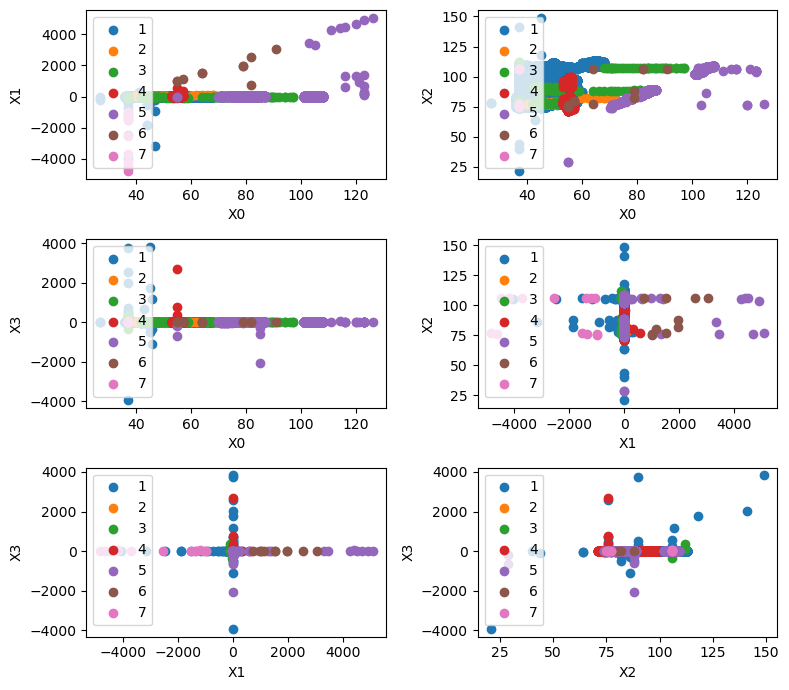

In [18]:
X = df.iloc[:, 0:4].values

fig, axes = plt.subplots(3, 2, figsize=(8, 7))
axes = axes.flatten(); j=0;

combinations = itertools.combinations([0,1,2,3], 2)

for col1, col2 in combinations:
    for cls in np.unique(y):
        axes[j].scatter(X[y == cls, col1], X[y == cls, col2], label=str(cls))
    axes[j].legend(loc='upper left')
    axes[j].set_xlabel(df.columns[col1])
    axes[j].set_ylabel(df.columns[col2])
    j=j+1    
    
fig.tight_layout()
plt.show()

The scatterplots for **X0 to X3** show that several classes form identifiable clusters, although some overlap is visible in a few feature combinations. This suggests that the predictors already contain meaningful class information. Even where separation is not perfect in two dimensions, the patterns indicate that the classes may become more distinguishable when all variables are used together.

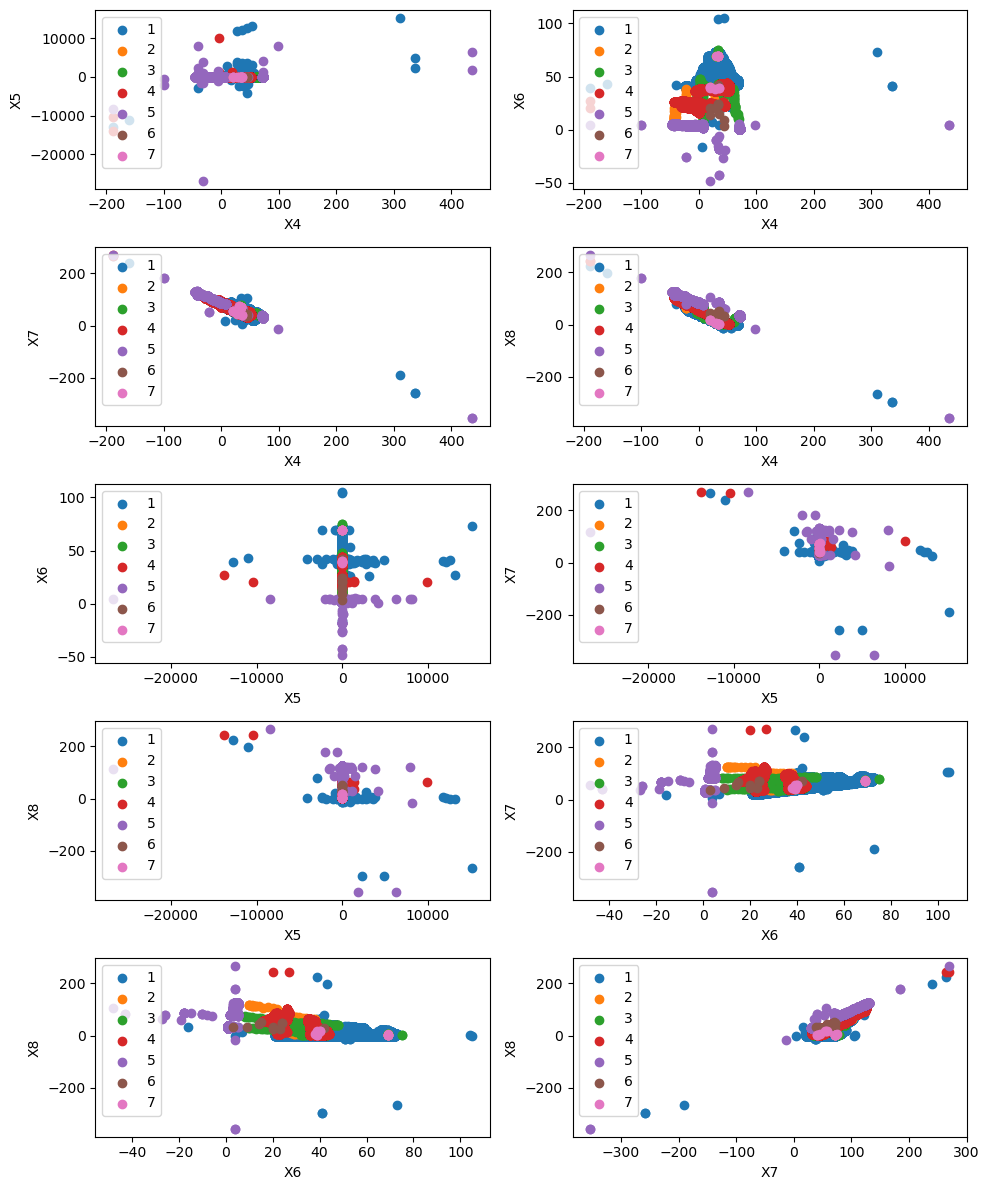

In [20]:
X = df.iloc[:, 4:9].values

fig, axes = plt.subplots(5, 2, figsize=(10, 12))
axes = axes.flatten(); j=0;

combinations = itertools.combinations([0,1,2,3,4], 2)

for col1, col2 in combinations:
    for cls in np.unique(y):
        axes[j].scatter(X[y == cls, col1], X[y == cls, col2], label=str(cls))
    axes[j].legend(loc='upper left')
    axes[j].set_xlabel(df.columns[col1+4])
    axes[j].set_ylabel(df.columns[col2+4])
    j=j+1    
    
fig.tight_layout()
plt.show()

The scatterplots for **X4 to X8** show clearer separation among classes in several variable pairs. This supports the use of classification methods based on decision boundaries. The boundaries may not be purely linear for all classes, but the structure in these plots strongly suggests that high classification accuracy should be achievable with flexible models.

In [22]:
means = df.groupby(df.columns[9]).mean()
print(means)

              X0           X1         X2        X3         X4        X5  \
Class                                                                     
1      43.992322    -0.501228  84.729062  0.308604  39.265038  2.245843   
2      53.180000    37.260000  78.760000  0.000000  -5.360000  0.380000   
3      54.450292   -48.935673  91.602339 -0.017544  27.520468 -4.029240   
4      55.439852     0.225991  86.595417  0.515781  21.745254 -1.435022   
5      87.434037    12.997551  90.336088 -1.115396   4.651974  1.340986   
6      70.800000  1653.800000  90.200000 -1.900000  32.800000 -4.900000   
7      37.000000 -2522.076923  92.230769  5.153846  30.307692  0.769231   

              X6         X7         X8  
Class                                   
1      40.749660  45.448734   4.894924  
2      25.640000  84.920000  59.320000  
3      37.105263  64.087719  27.157895  
4      30.979782  65.200382  34.173874  
5       2.873584  86.446893  83.444751  
6      19.400000  57.100000  37.60000

The class means differ noticeably across many variables, which confirms that the classes have distinct feature profiles. This suggests that the predictors are informative and that classification is appropriate for this dataset. Overall, the exploratory analysis indicates that models using decision boundaries should perform well, especially methods that can capture both linear and nonlinear separation.

# c) #

In [25]:
#Logistic Regression
clf_L = LogisticRegression(max_iter=10000, solver="lbfgs", tol=1e-3)

clf_L.fit(X_train, y_train)
y_pred = clf_L.predict(X_test)

# training accuracy
y_trainpred = clf_L.predict(X_train)
print(f'train accuracy: {clf_L.score(X_train, y_train):.2f}')

# test accuracy
y_pred = clf_L.predict(X_test)
print(f'test accuracy: {clf_L.score(X_test, y_test):.2f}')

train accuracy: 0.97
test accuracy: 0.97


Logistic Regression achieved about **97% training accuracy** and **97% test accuracy**. This is clearly better than the No Information Rate of **79.8%**, so the model does learn meaningful structure in the data. However, its performance is still noticeably below the best models, suggesting that the class boundaries are not fully captured by a simple linear decision rule.

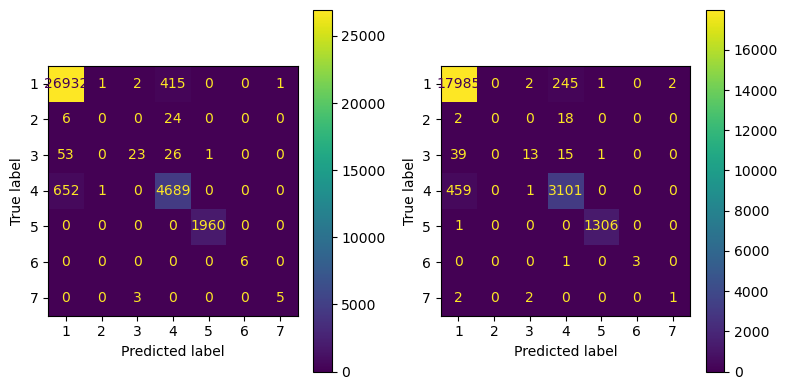

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

ConfusionMatrixDisplay.from_predictions(y_train, y_trainpred, ax=axes[0])
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[1])

plt.tight_layout()
plt.show()

In [28]:
#Linear Discriminant Analysis (LDA)
clf_D=LinearDiscriminantAnalysis()

clf_D.fit(X_train, y_train)
y_pred = clf_D.predict(X_test)

#training accuracy
y_trainpred=clf_D.predict(X_train)
print(np.mean(y_trainpred == y_train))

#test accuracy
y_pred = clf_D.predict(X_test)
print(clf_D.score(X_test, y_test))

0.943764367816092
0.9432327586206897


LDA achieved about **94% training accuracy** and **94% test accuracy**, which is above the No Information Rate but slightly worse than Logistic Regression. This suggests that while the dataset does have some linear separability, the assumptions of LDA are likely too restrictive for this problem. Therefore, LDA is not the best choice for maximizing classification accuracy on this dataset

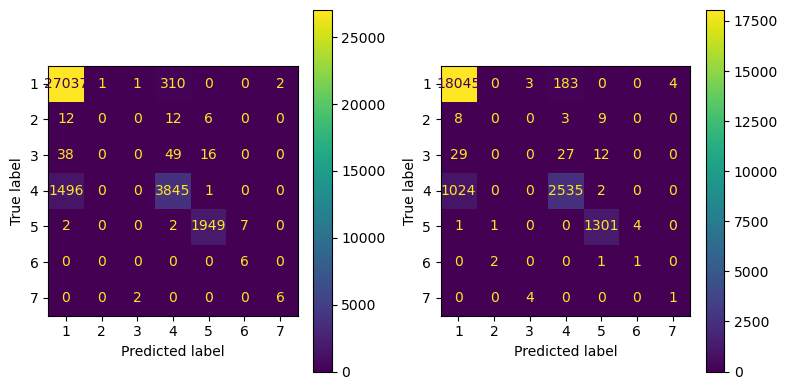

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

ConfusionMatrixDisplay.from_predictions(y_train, y_trainpred, ax=axes[0])
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[1])

plt.tight_layout()
plt.show()

In [31]:
#Support Vector Machines (SVM)
pipe_lr = make_pipeline(StandardScaler(),PCA(n_components=9), svm.SVC(max_iter=10000))


pipe_lr.fit(X_train, y_train)
y_pred = pipe_lr.predict(X_test)

# training accuracy
y_trainpred=pipe_lr.predict(X_train)
print(np.mean(y_trainpred == y_train))

# test accuracy
y_pred = pipe_lr.predict(X_test)
print(pipe_lr.score(X_test, y_test))

0.9984195402298851
0.9973275862068965


The SVM achieved approximately **99.84% training accuracy** and **99.73% test accuracy**, which is a major improvement over Logistic Regression and LDA. This indicates that the shuttle data is much better handled by a model that can create more flexible decision boundaries. Among the three models in part (c), **SVM performs best**, so it is the most suitable choice of the three for this dataset.

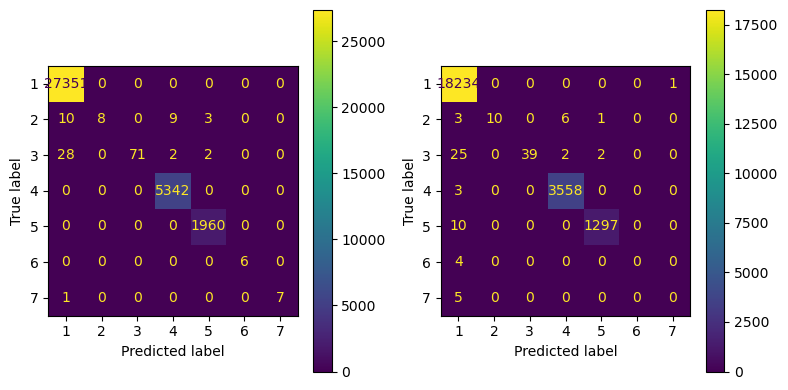

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

ConfusionMatrixDisplay.from_predictions(y_train, y_trainpred, ax=axes[0])
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[1])

plt.tight_layout()
plt.show()

# d) #

In [35]:
#Multilayer Perceptron
pipe_clf = make_pipeline(StandardScaler(), PCA(n_components=9),
                    MLPClassifier(hidden_layer_sizes=(20,), random_state=1, max_iter=1000))


pipe_clf.fit(X_train, y_train)
    

#training accuracy
y_trainpred=pipe_clf.predict(X_train)
print(np.mean(y_trainpred == y_train))

#test accuracy
y_pred = pipe_clf.predict(X_test)
print(pipe_clf.score(X_test, y_test), '\n')

0.9997413793103448
0.9990086206896551 



The MLP produced about **99.97% training accuracy** and **99.90% test accuracy**, showing extremely strong performance on both sets. The very small gap between training and test accuracy suggests that the model generalizes well and is not suffering from serious overfitting. This confirms that the shuttle dataset can be classified very effectively using a flexible nonlinear model.

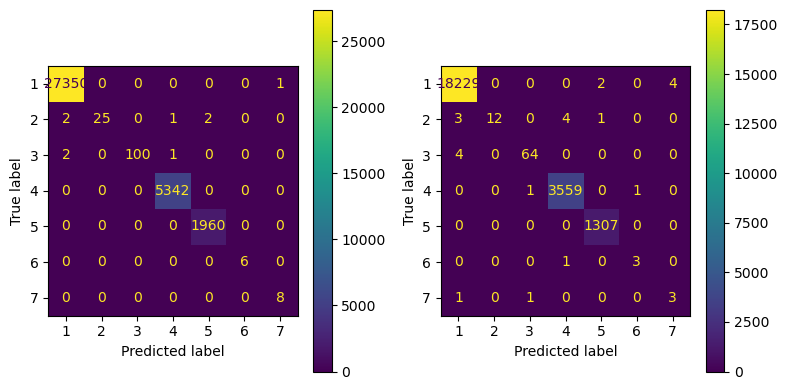

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

ConfusionMatrixDisplay.from_predictions(y_train, y_trainpred, ax=axes[0])
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[1])

plt.tight_layout()
plt.show()

In [38]:
#Decision Tree
tree_model = DecisionTreeClassifier()


tree_model.fit(X_train, y_train)
y_pred = tree_model.predict(X_test)

# training accuracy
y_trainpred=tree_model.predict(X_train)
print(np.mean(y_trainpred == y_train))

# test accuracy
y_pred = tree_model.predict(X_test)
print(tree_model.score(X_test, y_test))

1.0
0.9992241379310345


The Decision Tree achieved **100% training accuracy** and about **99.92% test accuracy**. The perfect training accuracy shows that the tree fits the training data completely, which is expected for a highly flexible model. Although the test accuracy is also excellent, the slight drop compared with training performance suggests a small amount of overfitting relative to more stable ensemble methods.

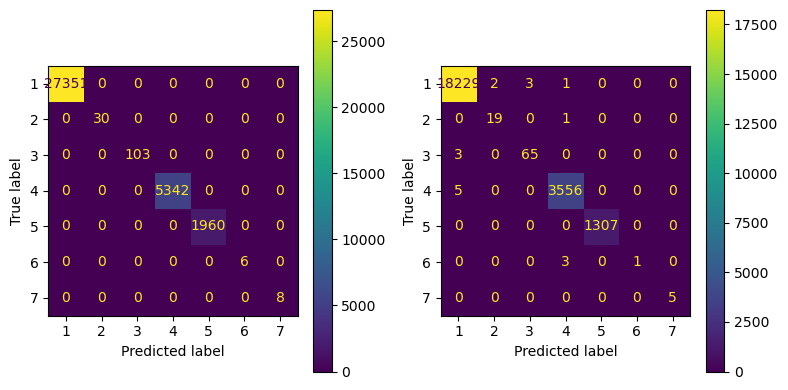

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

ConfusionMatrixDisplay.from_predictions(y_train, y_trainpred, ax=axes[0])
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[1])

plt.tight_layout()
plt.show()

In [41]:
#Random Forest
forest = RandomForestClassifier()
forest.fit(X_train, y_train)

# train accuracy
y_trainpred = forest.predict(X_train)
print(np.mean(y_trainpred == y_train))

# test accuracy
y_pred = forest.predict(X_test)
print(np.mean(y_pred == y_test))

1.0
0.9997413793103448


The Random Forest achieved **100% training accuracy** and about **99.97% test accuracy**, which is the best result among all models tested. This indicates that the model captures the complex structure of the data extremely well while also generalizing better than a single Decision Tree. Therefore, the **Random Forest is the best overall model** for this dataset.

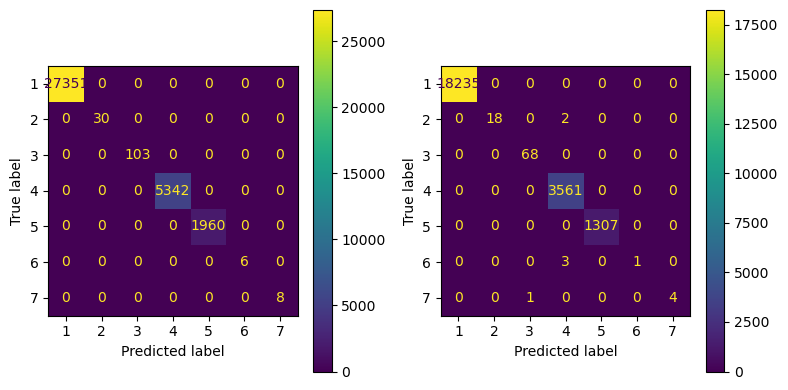

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

ConfusionMatrixDisplay.from_predictions(y_train, y_trainpred, ax=axes[0])
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[1])

plt.tight_layout()
plt.show()

## Question-2: ##

In [45]:
df = pd.read_csv('fish_toxicity.csv',sep=';')
print(df.head())
print('shape of the dataset:',df.shape)

    CIC0   SM1_Dz   GATS1i   NdsCH   NdssC   MLOGP   LC50
0  3.260    0.829    1.676       0       1   1.453  3.770
1  2.189    0.580    0.863       0       0   1.348  3.115
2  2.125    0.638    0.831       0       0   1.348  3.531
3  3.027    0.331    1.472       1       0   1.807  3.510
4  2.094    0.827    0.860       0       0   1.886  5.390
shape of the dataset: (908, 7)


In [46]:
print(df[df.isnull().any(axis=1)])

Empty DataFrame
Columns: [CIC0,  SM1_Dz,  GATS1i,  NdsCH,  NdssC,  MLOGP,  LC50]
Index: []


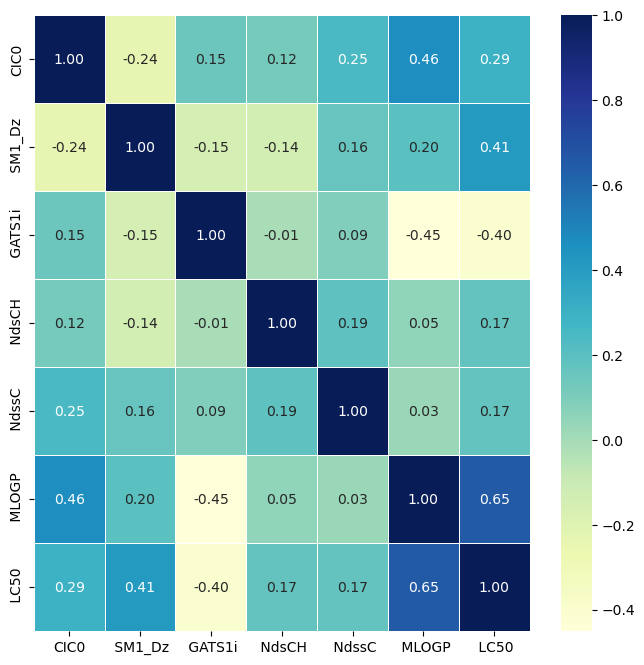

In [47]:
corr=df.corr()

plt.figure(figsize=(8, 8))
sb.heatmap(corr, annot=True, fmt=".2f", linewidths=.5, cmap='YlGnBu')

plt.show()

The heatmap indicates moderate correlations between predictors and LC50, with MLOGP showing the strongest positive relationship (≈ 0.65). SM1_Dz is also moderately correlated, while GATS1i shows a negative relationship. Other variables have weak correlations, suggesting limited individual predictive power. Overall, the moderate relationships explain why regression models achieve only moderate performance.

In [49]:
for i in [0,1,2,3,4,5]:
    correlation, p_value = stats.pearsonr(df.iloc[:,i], df.iloc[:, 6])
    print(df.columns[i], f"P-value: {p_value:4f}")
    print("-"* 30)

CIC0 P-value: 0.000000
------------------------------
 SM1_Dz P-value: 0.000000
------------------------------
 GATS1i P-value: 0.000000
------------------------------
 NdsCH P-value: 0.000000
------------------------------
 NdssC P-value: 0.000000
------------------------------
 MLOGP P-value: 0.000000
------------------------------


All predictors have p-values close to zero, indicating statistically significant relationships with LC50. However, despite this significance, some variables exhibit weak correlations, meaning their individual predictive strength is limited.

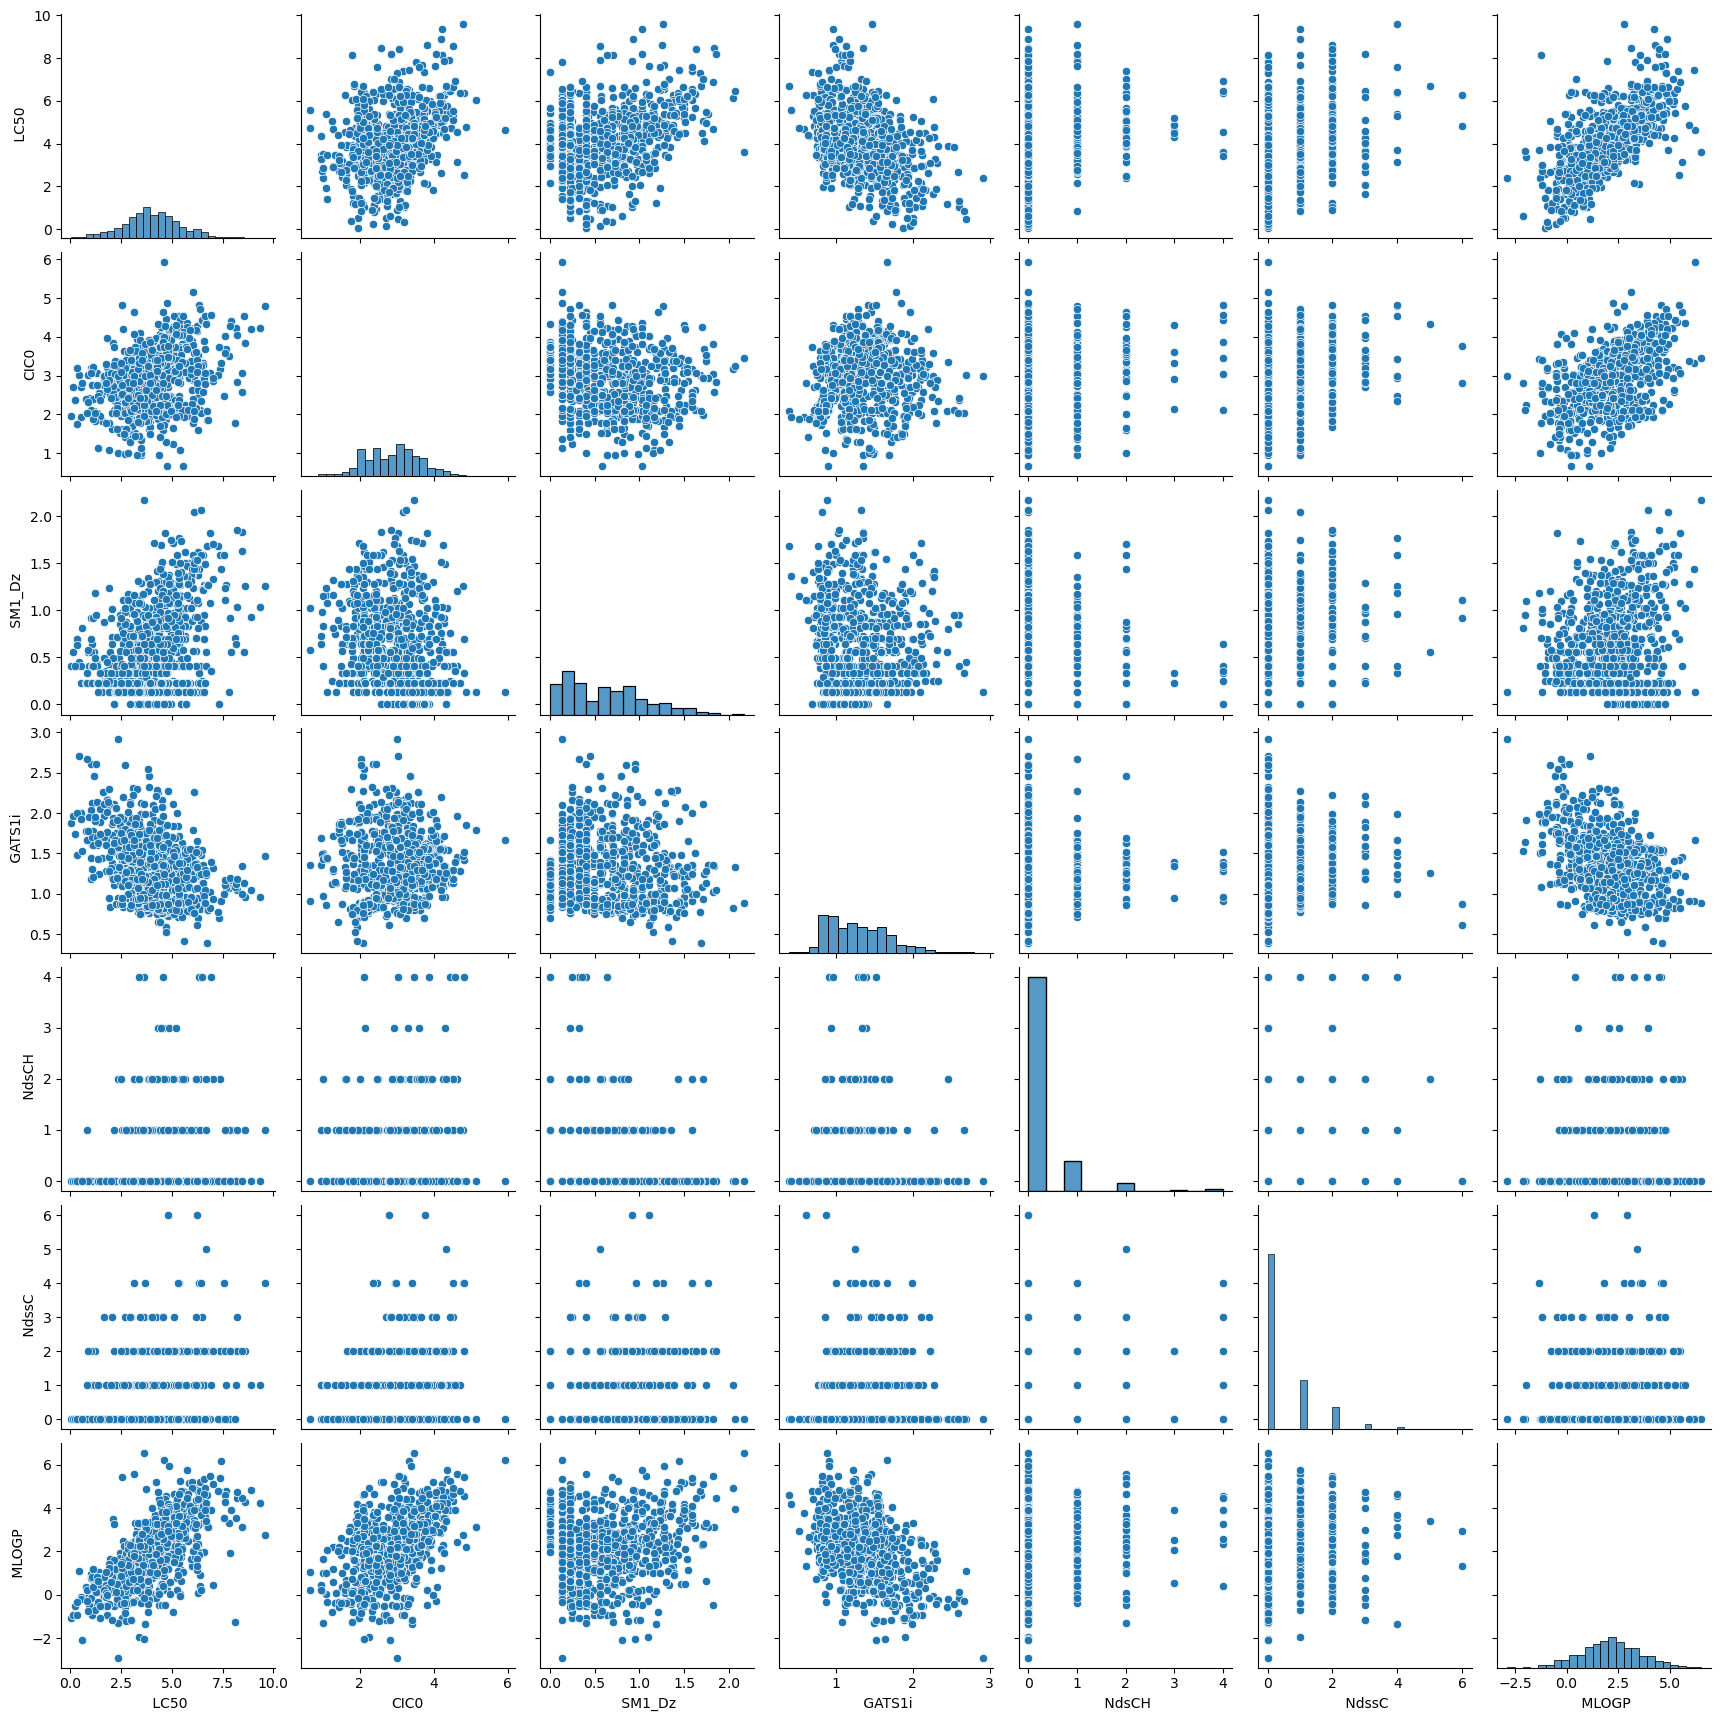

In [51]:
sb.pairplot(df.iloc[:, [6, 0, 1, 2, 3, 4, 5]])
plt.show()

The pairplot shows moderate relationships between LC50 and some predictors, particularly MLOGP and SM1_Dz, while GATS1i shows a negative trend. However, the relationships are scattered and not strongly linear, and some variables are discrete, which limits predictive performance.

In [53]:
variables = [n for n in range(0, 6)]

X = df.iloc[:, variables]
y = df.iloc[:, 6]

In [54]:
X_sm = sm.add_constant(X)
model = sm.OLS(y, X_sm)
results = model.fit()

print(results.params)
print(results.summary())

const      2.174560
CIC0       0.385626
 SM1_Dz    1.255622
 GATS1i   -0.746414
 NdsCH     0.413550
 NdssC     0.064334
 MLOGP     0.390053
dtype: float64
                            OLS Regression Results                            
Dep. Variable:                   LC50   R-squared:                       0.577
Model:                            OLS   Adj. R-squared:                  0.574
Method:                 Least Squares   F-statistic:                     205.0
Date:                Fri, 27 Mar 2026   Prob (F-statistic):          1.33e-164
Time:                        10:10:14   Log-Likelihood:                -1238.0
No. Observations:                 908   AIC:                             2490.
Df Residuals:                     901   BIC:                             2524.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t| 

The OLS model achieves a moderate R^2 (≈ 0.577), indicating partial explanatory power. Most predictors are statistically significant, with SM1_Dz and MLOGP showing strong positive effects and GATS1i a negative effect. However, NdssC is not significant, and the moderate R^2 suggests that the linear model does not fully capture the variability in LC50.

In [56]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=1)

In [57]:
slr = make_pipeline(StandardScaler(),LinearRegression())

slr.fit(X_train, y_train)
y_train_pred = slr.predict(X_train)
y_test_pred = slr.predict(X_test)

In [58]:
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)
print(f'R^2 train: {r2_train:.2f}')
print(f'R^2 test: {r2_test:.2f}')


mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
print(f'MSE train: {mse_train:.2f}')
print(f'MSE test: {mse_test:.2f}')

R^2 train: 0.60
R^2 test: 0.49
MSE train: 0.85
MSE test: 1.05


The linear model shows moderate performance (R^2 ≈ 0.60 train, 0.49 test) with a small gap indicating mild overfitting. The results suggest reasonable generalization but limited predictive power.

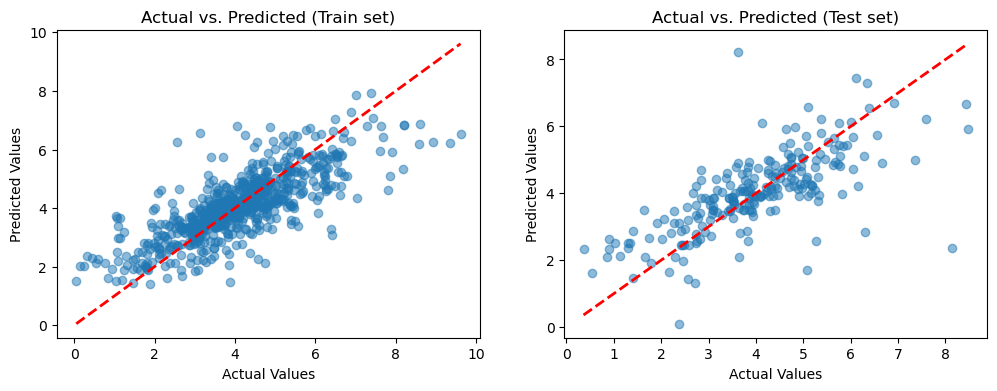

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_train, y_train_pred, alpha=0.5)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Values')
axes[0].set_ylabel('Predicted Values')
axes[0].set_title('Actual vs. Predicted (Train set)')

axes[1].scatter(y_test, y_test_pred, alpha=0.5)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Values')
axes[1].set_ylabel('Predicted Values')
axes[1].set_title('Actual vs. Predicted (Test set)')
plt.show()

In [61]:
poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train)
              
y_train_pred_poly = model_poly.predict(X_train_poly)
y_test_pred_poly = model_poly.predict(X_test_poly)

In [62]:
r2_train = r2_score(y_train, y_train_pred_poly)
r2_test = r2_score(y_test, y_test_pred_poly)
print(f'R^2 train: {r2_train:.2f}')
print(f'R^2 test: {r2_test:.2f}')

mse_train = mean_squared_error(y_train, y_train_pred_poly)
mse_test = mean_squared_error(y_test, y_test_pred_poly)
print(f'MSE train: {mse_train:.2f}')
print(f'MSE test: {mse_test:.2f}')

R^2 train: 0.66
R^2 test: 0.44
MSE train: 0.72
MSE test: 1.14


The polynomial regression model (degree 2) shows an increase in training performance (R^2 = 0.66) compared to the linear model, indicating that adding nonlinear terms allows the model to better fit the training data. However, the test R^2 decreases to 0.44, and the test MSE increases to 1.14, which suggests that the model does not generalize well to unseen data.

The noticeable gap between training and test performance indicates overfitting, meaning the model is capturing noise in the training data rather than the true underlying relationship. Therefore, although polynomial features improve the fit on the training set, they do not lead to better predictive performance overall.

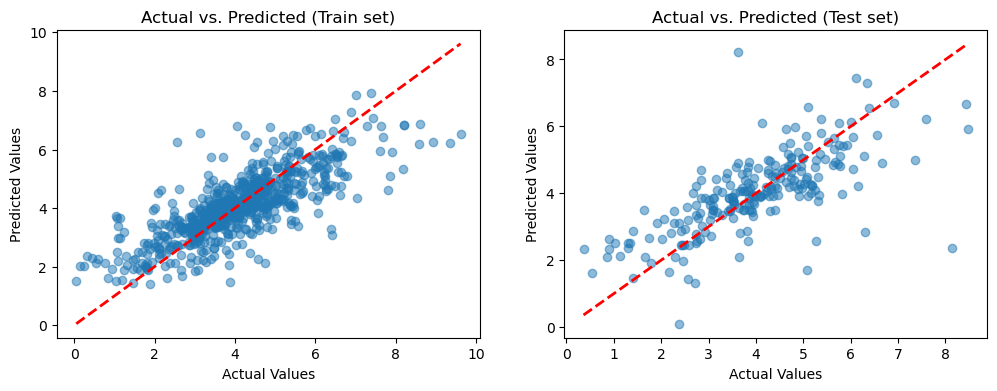

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_train, y_train_pred, alpha=0.5)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Values')
axes[0].set_ylabel('Predicted Values')
axes[0].set_title('Actual vs. Predicted (Train set)')

axes[1].scatter(y_test, y_test_pred, alpha=0.5)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Values')
axes[1].set_ylabel('Predicted Values')
axes[1].set_title('Actual vs. Predicted (Test set)')
plt.show()

In [65]:
poly = PolynomialFeatures(degree=3)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train)
              
y_train_pred_poly = model_poly.predict(X_train_poly)
y_test_pred_poly = model_poly.predict(X_test_poly)

In [66]:
r2_train = r2_score(y_train, y_train_pred_poly)
r2_test = r2_score(y_test, y_test_pred_poly)
print(f'R^2 train: {r2_train:.2f}')
print(f'R^2 test: {r2_test:.2f}')

mse_train = mean_squared_error(y_train, y_train_pred_poly)
mse_test = mean_squared_error(y_test, y_test_pred_poly)
print(f'MSE train: {mse_train:.2f}')
print(f'MSE test: {mse_test:.2f}')

R^2 train: 0.73
R^2 test: 0.48
MSE train: 0.58
MSE test: 1.07


The polynomial regression model with degree 3 further improves the training performance (R^2 = 0.73) compared to lower-degree models, indicating that the model is able to fit the training data more closely. However, the test R^2 remains low (0.48) and is similar to the linear model, while the test MSE (1.07) is still relatively high.

The increasing gap between training and test performance clearly indicates strong overfitting, as the model becomes too complex and starts capturing noise rather than the true underlying relationship. Therefore, although higher-degree polynomial features improve training accuracy, they do not lead to better generalization and are not suitable for this dataset.

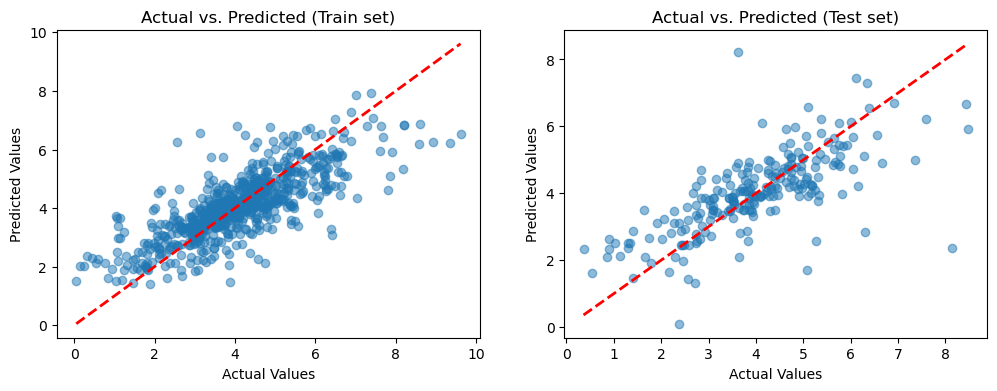

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_train, y_train_pred, alpha=0.5)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Values')
axes[0].set_ylabel('Predicted Values')
axes[0].set_title('Actual vs. Predicted (Train set)')

axes[1].scatter(y_test, y_test_pred, alpha=0.5)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Values')
axes[1].set_ylabel('Predicted Values')
axes[1].set_title('Actual vs. Predicted (Test set)')
plt.show()

In [69]:
ransac = make_pipeline(StandardScaler(),RANSACRegressor(LinearRegression(), max_trials=200, min_samples=0.7, loss='absolute_error', residual_threshold=None, random_state=1))

ransac.fit(X_train, y_train)
y_train_pred = ransac.predict(X_train)
y_test_pred = ransac.predict(X_test)

In [70]:
r2_train = r2_score(y_train, y_train_pred)
r2_test =r2_score(y_test, y_test_pred)
print(f'R^2 train: {r2_train:.2f}')
print(f'R^2 test: {r2_test:.2f}')

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
print(f'MSE train: {mse_train:.2f}')
print(f'MSE test: {mse_test:.2f}')

R^2 train: 0.60
R^2 test: 0.50
MSE train: 0.86
MSE test: 1.03


The RANSAC regression model achieves an R^2 of 0.60 on the training set and 0.50 on the test set, which is very similar to the standard linear regression model. The small gap between training and test performance indicates good generalization with minimal overfitting.

The MSE values (0.86 for training and 1.03 for testing) are also comparable to the linear model, suggesting no significant improvement in predictive accuracy. Since RANSAC is designed to handle outliers, the similar performance indicates that outliers are not a major issue in this dataset. Therefore, robust regression does not provide a meaningful advantage over the standard linear model.

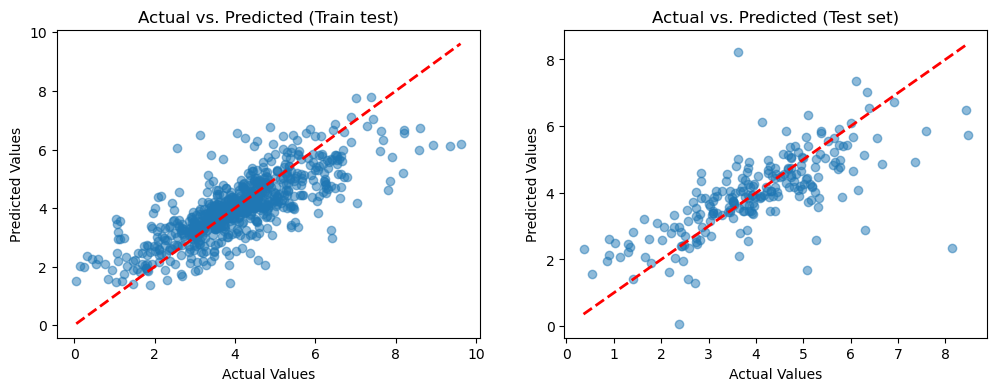

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_train, y_train_pred, alpha=0.5)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Values')
axes[0].set_ylabel('Predicted Values')
axes[0].set_title('Actual vs. Predicted (Train test)')

axes[1].scatter(y_test, y_test_pred, alpha=0.5)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Values')
axes[1].set_ylabel('Predicted Values')
axes[1].set_title('Actual vs. Predicted (Test set)')
plt.show()

In [73]:
alphas = np.arange(0.25, 6.0, 0.25)
ridge = make_pipeline(StandardScaler(), RidgeCV(alphas=alphas, cv=5))
ridge.fit(X_train, y_train)

y_train_pred = ridge.predict(X_train)
y_test_pred = ridge.predict(X_test)

print("Optimal alpha selected by RidgeCV:", ridge.named_steps['ridgecv'].alpha_)

Optimal alpha selected by RidgeCV: 5.75


In [74]:
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
print(f'R^2 train: {train_r2:.3f}, test: {test_r2:.3f}')

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
print(f'MSE train: {train_mse:.3f}, test: {test_mse:.3f}')

R^2 train: 0.603, test: 0.488
MSE train: 0.848, test: 1.050


The Ridge regression model, with an optimal regularization parameter α = 5.75, achieves an R^2 of 0.603 on the training set and 0.488 on the test set, which is very similar to the standard linear regression model. The MSE values (0.848 for training and 1.050 for testing) also show no meaningful improvement in predictive accuracy.

The similar performance indicates that multicollinearity is not a major issue in this dataset. Therefore, regularization does not significantly enhance model performance, and the linear model remains equally effective.

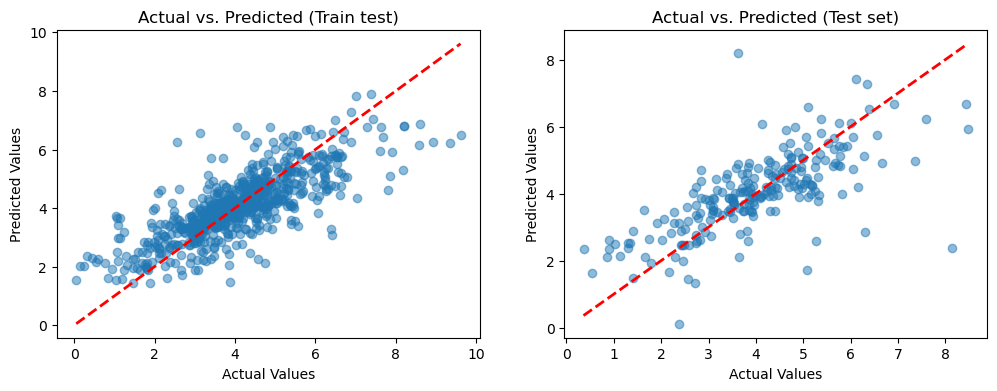

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_train, y_train_pred, alpha=0.5)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Values')
axes[0].set_ylabel('Predicted Values')
axes[0].set_title('Actual vs. Predicted (Train test)')

axes[1].scatter(y_test, y_test_pred, alpha=0.5)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Values')
axes[1].set_ylabel('Predicted Values')
axes[1].set_title('Actual vs. Predicted (Test set)')
plt.show()

In [77]:
from sklearn.linear_model import LassoCV

alphas = np.arange(0.25, 6.0, 0.25)

lasso = make_pipeline(StandardScaler(), LassoCV(alphas=alphas, cv=5, max_iter=10000))
lasso.fit(X_train, y_train)

y_train_pred = lasso.predict(X_train)
y_test_pred = lasso.predict(X_test)

print("Optimal alpha selected by LassoCV:", lasso.named_steps['lassocv'].alpha_)

Optimal alpha selected by LassoCV: 0.25


In [78]:
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)
print(f'R^2 train: {r2_train:.2f}')
print(f'R^2 test: {r2_test:.2f}')

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
print(f'MSE train: {mse_train:.2f}')
print(f'MSE test: {mse_test:.2f}')

R^2 train: 0.47
R^2 test: 0.45
MSE train: 1.12
MSE test: 1.14


The Lasso regression model selects an optimal regularization parameter α = 0.25 and achieves an R^2 of 0.47 on the training set and 0.45 on the test set, which is lower than the standard linear and Ridge regression models. The MSE values (1.12 for training and 1.14 for testing) are also higher, indicating reduced predictive performance.

The regularization appears to be too strong, leading to underfitting. As a result, important information from the predictors may be lost, causing a decline in model accuracy. Therefore, Lasso does not improve performance for this dataset.

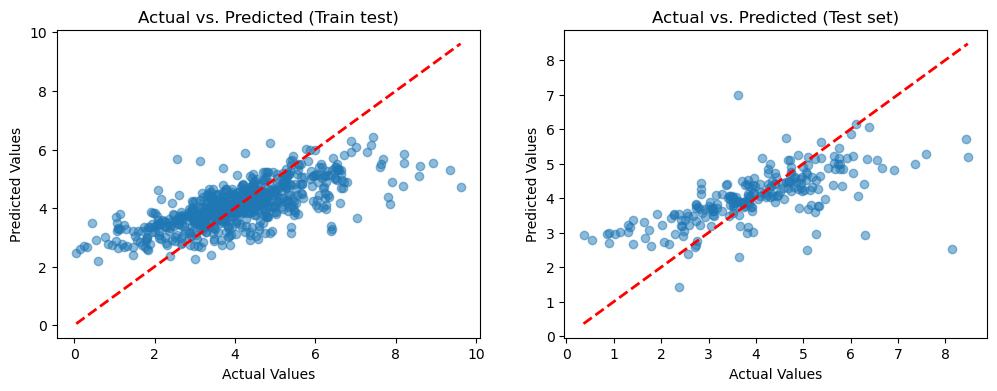

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_train, y_train_pred, alpha=0.5)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Values')
axes[0].set_ylabel('Predicted Values')
axes[0].set_title('Actual vs. Predicted (Train test)')

axes[1].scatter(y_test, y_test_pred, alpha=0.5)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Values')
axes[1].set_ylabel('Predicted Values')
axes[1].set_title('Actual vs. Predicted (Test set)')
plt.show()

Among all models considered, none provides a substantial improvement over the standard linear regression model. The linear model achieves moderate performance and generalizes reasonably well, indicating that it captures part of the relationship between the molecular descriptors and LC50.

The polynomial models (degree 2 and 3) improve training performance but show worse test performance, clearly indicating overfitting due to increased model complexity. The robust regression model (RANSAC) produces results very similar to the linear model, suggesting that outliers are not a significant issue in this dataset.

Ridge regression also performs similarly to the linear model, indicating that multicollinearity is not a major concern. In contrast, Lasso regression shows lower performance, likely due to excessive regularization leading to underfitting and loss of important predictor information.

Overall, the moderate R^2 values across all models suggest that the available molecular descriptors only partially explain LC50. Therefore, the standard linear regression model remains a reasonable and interpretable choice, and increasing model complexity or applying regularization does not lead to meaningful improvements in predictive performance.